# ODIF — PR AUC Accuracy Evaluation
Evaluates **OptimizedDeepIF**, **DeepIF**, and **IsolationForest** on 18 benchmark datasets.

Datasets are split into **3 groups** — run one group at a time, then view the rolling summary.

| Group | Datasets | Scale |
|-------|----------|-------|
| 1 | Glass, Wine, Ionosphere, Vowels, Letter, Waveform | Small/Medium |
| 2 | Fault, Landsat, Satellite, Satimage-2, PageBlocks, Wilt | Medium |
| 3 | ALOI, Backdoor, Fraud, Mnist, Skin, Smtp | Large |

## Cell 1 — Imports & Setup

In [1]:
import sys
import os
import gc
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import average_precision_score
from IPython.display import display

try:
    import pynvml
    pynvml.nvmlInit()   # test if driver is actually available
    HAS_NVML = True
except Exception:
    import types
    pynvml_stub = types.ModuleType('pynvml')
    pynvml_stub.nvmlInit = lambda: None
    pynvml_stub.nvmlShutdown = lambda: None
    pynvml_stub.nvmlDeviceGetHandleByIndex = lambda i: None
    pynvml_stub.nvmlDeviceGetComputeRunningProcesses = lambda h: []
    sys.modules['pynvml'] = pynvml_stub
    HAS_NVML = False
# Make sure project root is on the path
sys.path.insert(0, '.')
from utils.AlgorithmFactory import AlgorithmFactory

# ── Visual style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = {'OptimizedDeepIF': '#2563eb', 'DeepIF': '#16a34a', 'IsolationForest': '#dc2626', 'ECOD': '#d97706'}

# ── Dataset registry ──────────────────────────────────────────────────────────
GROUPS = {
    1: [
        {'source': 'glass',       'name': 'Glass'},
        {'source': 'wine',        'name': 'Wine'},
        {'source': 'ionosphere',  'name': 'Ionosphere'},
        {'source': 'vowels',      'name': 'Vowels'},
        {'source': 'letter',      'name': 'Letter'},
        {'source': 'waveform',    'name': 'Waveform'},
    ],
    2: [
        {'source': 'fault',       'name': 'Fault'},
        {'source': 'landsat',     'name': 'Landsat'},
        {'source': 'satellite',   'name': 'Satellite'},
        {'source': 'satimage-2',  'name': 'Satimage-2'},
        {'source': 'page_blocks', 'name': 'PageBlocks'},
        {'source': 'wilt',        'name': 'Wilt'},
    ],
    3: [
        {'source': 'aloi',        'name': 'ALOI'},
        {'source': 'backdoor',    'name': 'Backdoor'},
        {'source': 'fraud',       'name': 'Fraud'},
        {'source': 'mnist',       'name': 'Mnist'},
        {'source': 'skin',        'name': 'Skin'},
        {'source': 'smtp',        'name': 'Smtp'},
    ],
}

ALGORITHM_NAMES = ['OptimizedDeepIF', 'DeepIF', 'IsolationForest', 'ECOD']

# Accumulates results across groups
all_results = []

print('✅ Setup complete. Device:', 'cuda' if torch.cuda.is_available() else 'cpu')

✅ Setup complete. Device: cpu


## Cell 2 — Core Helper Functions

In [2]:
def load_dataset(source: str):
    """Load a CSV dataset. Returns (X, y) as numpy arrays."""
    path = os.path.join('datasets', source + '.csv')
    df = pd.read_csv(path, sep=',', dtype=np.float64, engine='python')
    data = df.values
    X = data[:, :-1]
    y = data[:, -1]
    return X, y


def evaluate_algorithm(algorithm_name: str, X: np.ndarray, y: np.ndarray) -> float:
    """Fit an algorithm on X and return PR AUC against y."""
    algo = AlgorithmFactory.getAlgorithmFromName(algorithm_name)
    algo.fit(X)
    scores = algo.decision_function(X)
    pr_auc = average_precision_score(y, scores) * 100  # as percentage
    del algo
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return round(pr_auc, 1)


def run_group(group_id: int) -> pd.DataFrame:
    """Run all algorithms on all datasets in a group. Returns a results DataFrame."""
    datasets = GROUPS[group_id]
    rows = []
    total = len(datasets) * len(ALGORITHM_NAMES)
    done = 0

    for ds in datasets:
        print(f"\n📂 {ds['name']}  ({ds['source']}.csv)")
        X, y = load_dataset(ds['source'])
        print(f"   shape: {X.shape}  |  anomaly rate: {y.mean()*100:.1f}%")
        row = {'Dataset': ds['name']}

        for alg in ALGORITHM_NAMES:
            pr = evaluate_algorithm(alg, X, y)
            row[alg] = pr
            done += 1
            print(f"   [{done}/{total}] {alg:20s} → PR AUC: {pr:.1f}%")

        rows.append(row)

    df = pd.DataFrame(rows).set_index('Dataset')
    return df


print('✅ Helper functions defined.')

✅ Helper functions defined.


## Cell 3 — Plotting Functions

In [3]:
def plot_group_bars(df: pd.DataFrame, group_id: int):
    """Grouped bar chart — PR AUC per algorithm per dataset in a group."""
    datasets = df.index.tolist()
    n = len(datasets)
    x = np.arange(n)
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(8, n * 1.4), 5))
    for i, alg in enumerate(ALGORITHM_NAMES):
        bars = ax.bar(x + (i - 1) * width, df[alg], width,
                      label=alg, color=PALETTE[alg], alpha=0.88, zorder=3)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                    f'{h:.0f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=20, ha='right')
    ax.set_ylabel('PR AUC (%)')
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
    ax.set_title(f'Group {group_id} — PR AUC by Algorithm & Dataset', fontweight='bold')
    ax.legend(loc='upper right', framealpha=0.5)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    plt.tight_layout()
    plt.show()


def plot_summary_heatmap(df: pd.DataFrame):
    """Heatmap — all datasets × all algorithms (running total)."""
    fig, ax = plt.subplots(figsize=(7, max(4, len(df) * 0.45)))
    sns.heatmap(
        df[ALGORITHM_NAMES].astype(float),
        annot=True, fmt='.1f', cmap='YlGn',
        linewidths=0.4, linecolor='#e5e7eb',
        cbar_kws={'label': 'PR AUC (%)'},
        ax=ax
    )
    ax.set_title('PR AUC Heatmap — All Datasets So Far', fontweight='bold')
    ax.set_ylabel('')
    ax.set_xticklabels(ALGORITHM_NAMES, rotation=15, ha='right')
    plt.tight_layout()
    plt.show()


def plot_summary_boxplot(df: pd.DataFrame):
    """Box plot — PR AUC distribution per algorithm across all datasets so far."""
    data = [df[alg].values for alg in ALGORITHM_NAMES]
    fig, ax = plt.subplots(figsize=(7, 4))
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, alg in zip(bp['boxes'], ALGORITHM_NAMES):
        patch.set_facecolor(PALETTE[alg])
        patch.set_alpha(0.75)
    ax.set_xticklabels(ALGORITHM_NAMES, rotation=10)
    ax.set_ylabel('PR AUC (%)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
    ax.set_title('PR AUC Distribution — All Datasets So Far', fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


def show_summary_table(df: pd.DataFrame):
    """Styled summary table with average and median rows."""
    summary = df[ALGORITHM_NAMES].copy()
    avg_row = summary.mean().rename('Average')
    med_row = summary.median().rename('Median')
    summary = pd.concat([summary, avg_row.to_frame().T, med_row.to_frame().T])

    styled = (
        summary.style
        .format('{:.1f}%')
        .background_gradient(cmap='YlGn', subset=pd.IndexSlice[df.index, :])
        .set_caption('📊 PR AUC Results — All Datasets So Far')
        .set_properties(**{'text-align': 'center'})
        .apply(lambda row: ['font-weight: bold; background-color: #f0f9ff'
                             if row.name in ['Average', 'Median'] else ''
                             for _ in row], axis=1)
    )
    display(styled)


print('✅ Plot functions defined.')

✅ Plot functions defined.


---
## ▶ Group 1 — Small/Medium Datasets
**Glass, Wine, Ionosphere, Vowels, Letter, Waveform**

In [4]:
print('=' * 55)
print('  Running Group 1 — Small / Medium datasets')
print('=' * 55)
results_g1 = run_group(1)
all_results.append(results_g1)
print('\n✅ Group 1 done!')

  Running Group 1 — Small / Medium datasets

📂 Glass  (glass.csv)
   shape: (214, 9)  |  anomaly rate: 4.2%
   [1/24] OptimizedDeepIF      → PR AUC: 10.7%
   [2/24] DeepIF               → PR AUC: 14.2%
   [3/24] IsolationForest      → PR AUC: 9.7%
   [4/24] ECOD                 → PR AUC: 11.5%

📂 Wine  (wine.csv)
   shape: (129, 13)  |  anomaly rate: 7.8%
   [5/24] OptimizedDeepIF      → PR AUC: 35.8%
   [6/24] DeepIF               → PR AUC: 50.3%
   [7/24] IsolationForest      → PR AUC: 20.5%
   [8/24] ECOD                 → PR AUC: 19.1%

📂 Ionosphere  (ionosphere.csv)
   shape: (351, 33)  |  anomaly rate: 35.9%
   [9/24] OptimizedDeepIF      → PR AUC: 92.2%
   [10/24] DeepIF               → PR AUC: 92.1%
   [11/24] IsolationForest      → PR AUC: 79.4%
   [12/24] ECOD                 → PR AUC: 65.7%

📂 Vowels  (vowels.csv)
   shape: (1456, 12)  |  anomaly rate: 3.4%
   [13/24] OptimizedDeepIF      → PR AUC: 27.7%
   [14/24] DeepIF               → PR AUC: 25.3%
   [15/24] IsolationFor

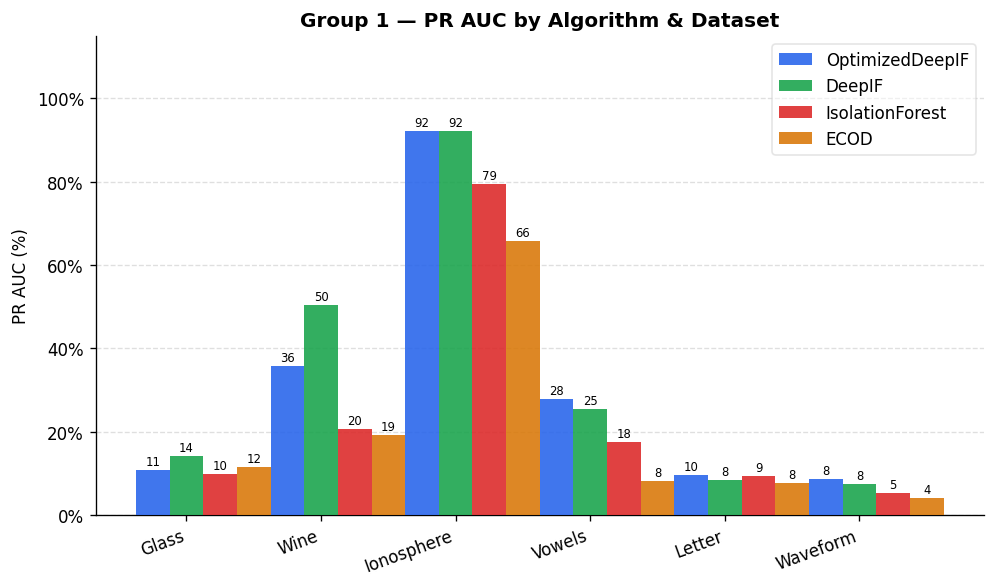

,OptimizedDeepIF,DeepIF,IsolationForest,ECOD
Glass,10.7%,14.2%,9.7%,11.5%
Wine,35.8%,50.3%,20.5%,19.1%
Ionosphere,92.2%,92.1%,79.4%,65.7%
Vowels,27.7%,25.3%,17.5%,8.1%
Letter,9.5%,8.3%,9.3%,7.7%
Waveform,8.5%,7.5%,5.2%,4.1%
Average,30.7%,33.0%,23.6%,19.4%
Median,19.2%,19.8%,13.6%,9.8%


In [5]:
# ── Group 1 visualisations ────────────────────────────────────────────────────
plot_group_bars(results_g1, group_id=1)

summary_so_far = pd.concat(all_results)
show_summary_table(summary_so_far)

---
## ▶ Group 2 — Medium Datasets
**Fault, Landsat, Satellite, Satimage-2, PageBlocks, Wilt**

In [6]:
print('=' * 55)
print('  Running Group 2 — Medium datasets')
print('=' * 55)
results_g2 = run_group(2)
all_results.append(results_g2)
print('\n✅ Group 2 done!')

  Running Group 2 — Medium datasets

📂 Fault  (fault.csv)
   shape: (1941, 27)  |  anomaly rate: 34.7%
   [1/24] OptimizedDeepIF      → PR AUC: 51.5%
   [2/24] DeepIF               → PR AUC: 48.4%
   [3/24] IsolationForest      → PR AUC: 41.0%
   [4/24] ECOD                 → PR AUC: 32.6%

📂 Landsat  (landsat.csv)
   shape: (6435, 36)  |  anomaly rate: 20.7%
   [5/24] OptimizedDeepIF      → PR AUC: 27.2%
   [6/24] DeepIF               → PR AUC: 25.3%
   [7/24] IsolationForest      → PR AUC: 19.6%
   [8/24] ECOD                 → PR AUC: 16.3%

📂 Satellite  (satellite.csv)
   shape: (6435, 36)  |  anomaly rate: 31.6%
   [9/24] OptimizedDeepIF      → PR AUC: 73.5%
   [10/24] DeepIF               → PR AUC: 73.6%
   [11/24] IsolationForest      → PR AUC: 64.8%
   [12/24] ECOD                 → PR AUC: 52.6%

📂 Satimage-2  (satimage-2.csv)
   shape: (5803, 36)  |  anomaly rate: 1.2%
   [13/24] OptimizedDeepIF      → PR AUC: 94.7%
   [14/24] DeepIF               → PR AUC: 94.1%
   [15/24] I

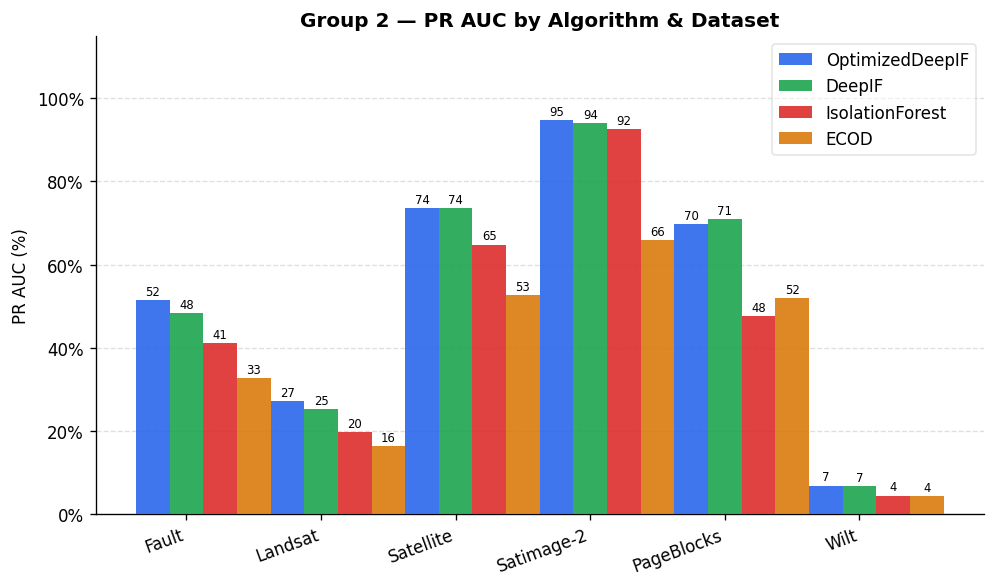

,OptimizedDeepIF,DeepIF,IsolationForest,ECOD
Glass,10.7%,14.2%,9.7%,11.5%
Wine,35.8%,50.3%,20.5%,19.1%
Ionosphere,92.2%,92.1%,79.4%,65.7%
Vowels,27.7%,25.3%,17.5%,8.1%
Letter,9.5%,8.3%,9.3%,7.7%
Waveform,8.5%,7.5%,5.2%,4.1%
Fault,51.5%,48.4%,41.0%,32.6%
Landsat,27.2%,25.3%,19.6%,16.3%
Satellite,73.5%,73.6%,64.8%,52.6%
Satimage-2,94.7%,94.1%,92.5%,66.0%


In [7]:
# ── Group 2 visualisations ────────────────────────────────────────────────────
plot_group_bars(results_g2, group_id=2)

summary_so_far = pd.concat(all_results)
show_summary_table(summary_so_far)

---
## ▶ Group 3 — Large Datasets
**ALOI, Backdoor, Fraud, Mnist, Skin, Smtp**

In [8]:
print('=' * 55)
print('  Running Group 3 — Large datasets')
print('=' * 55)
results_g3 = run_group(3)
all_results.append(results_g3)
print('\n✅ Group 3 done!')

  Running Group 3 — Large datasets

📂 ALOI  (aloi.csv)
   shape: (49534, 27)  |  anomaly rate: 3.0%
   [1/24] OptimizedDeepIF      → PR AUC: 4.6%
   [2/24] DeepIF               → PR AUC: 5.2%
   [3/24] IsolationForest      → PR AUC: 3.3%
   [4/24] ECOD                 → PR AUC: 3.3%

📂 Backdoor  (backdoor.csv)
   shape: (95329, 196)  |  anomaly rate: 2.4%
   [5/24] OptimizedDeepIF      → PR AUC: 35.0%
   [6/24] DeepIF               → PR AUC: 40.1%
   [7/24] IsolationForest      → PR AUC: 5.3%
   [8/24] ECOD                 → PR AUC: 9.2%

📂 Fraud  (fraud.csv)
   shape: (284807, 29)  |  anomaly rate: 0.2%
   [9/24] OptimizedDeepIF      → PR AUC: 37.8%
   [10/24] DeepIF               → PR AUC: 38.2%
   [11/24] IsolationForest      → PR AUC: 13.5%
   [12/24] ECOD                 → PR AUC: 21.7%

📂 Mnist  (mnist.csv)
   shape: (7603, 100)  |  anomaly rate: 9.2%
   [13/24] OptimizedDeepIF      → PR AUC: 61.2%
   [14/24] DeepIF               → PR AUC: 55.5%
   [15/24] IsolationForest      → 

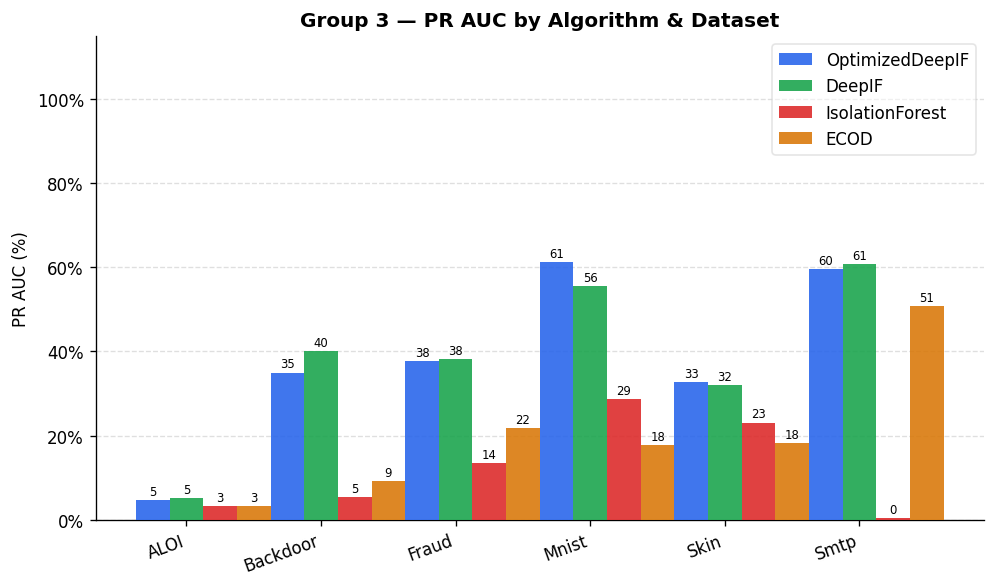

,OptimizedDeepIF,DeepIF,IsolationForest,ECOD
Glass,10.7%,14.2%,9.7%,11.5%
Wine,35.8%,50.3%,20.5%,19.1%
Ionosphere,92.2%,92.1%,79.4%,65.7%
Vowels,27.7%,25.3%,17.5%,8.1%
Letter,9.5%,8.3%,9.3%,7.7%
Waveform,8.5%,7.5%,5.2%,4.1%
Fault,51.5%,48.4%,41.0%,32.6%
Landsat,27.2%,25.3%,19.6%,16.3%
Satellite,73.5%,73.6%,64.8%,52.6%
Satimage-2,94.7%,94.1%,92.5%,66.0%


In [9]:
# ── Group 3 visualisations ────────────────────────────────────────────────────
plot_group_bars(results_g3, group_id=3)

summary_so_far = pd.concat(all_results)
show_summary_table(summary_so_far)

---
## 📊 Final Summary — All 18 Datasets
*Run this cell only after all 3 groups are complete.*

,OptimizedDeepIF,DeepIF,IsolationForest,ECOD
Glass,10.7%,14.2%,9.7%,11.5%
Wine,35.8%,50.3%,20.5%,19.1%
Ionosphere,92.2%,92.1%,79.4%,65.7%
Vowels,27.7%,25.3%,17.5%,8.1%
Letter,9.5%,8.3%,9.3%,7.7%
Waveform,8.5%,7.5%,5.2%,4.1%
Fault,51.5%,48.4%,41.0%,32.6%
Landsat,27.2%,25.3%,19.6%,16.3%
Satellite,73.5%,73.6%,64.8%,52.6%
Satimage-2,94.7%,94.1%,92.5%,66.0%


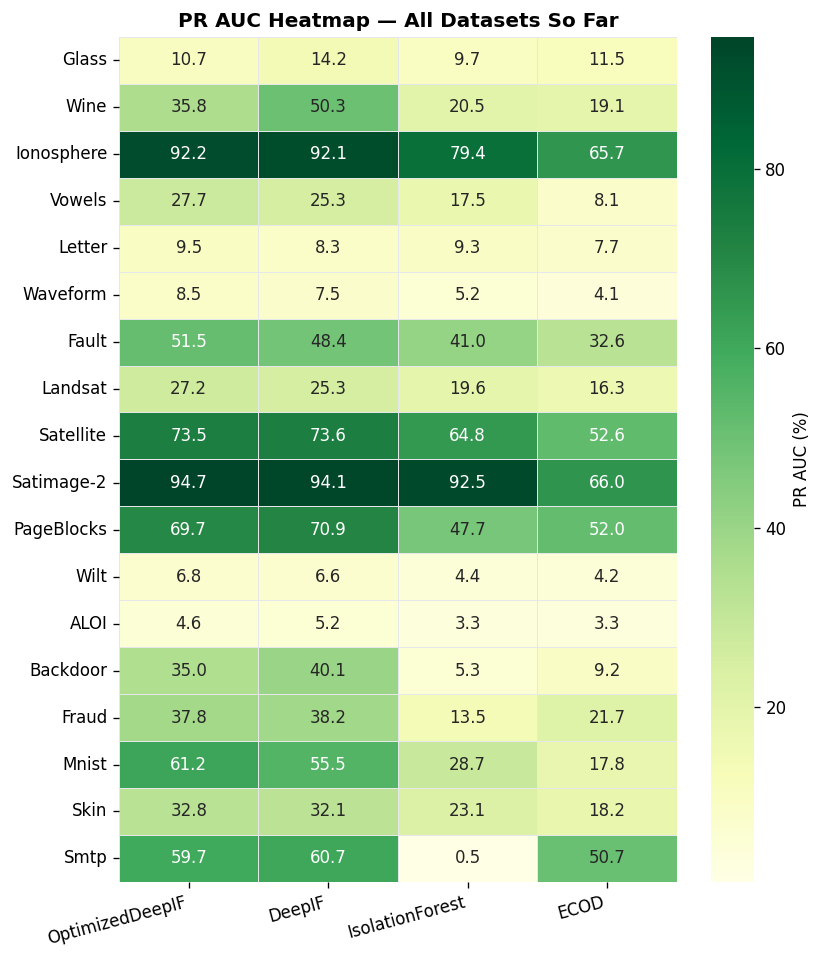

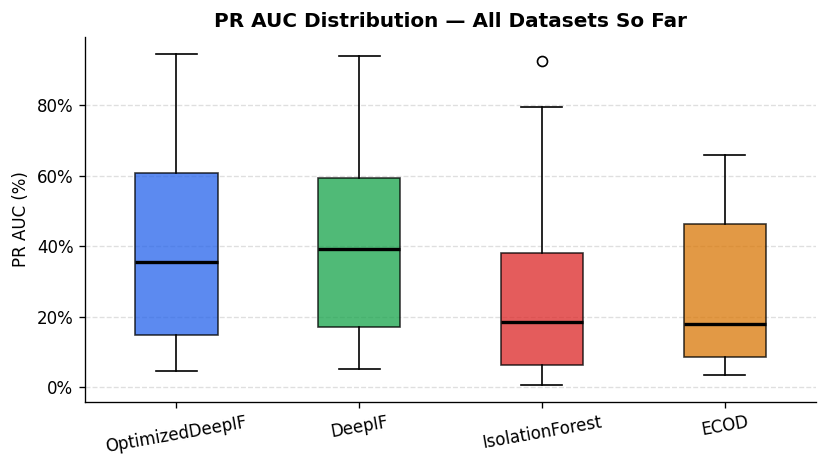


── Average PR AUC across all 18 datasets ──
  OptimizedDeepIF       : 41.0%  (median: 35.4%)
  DeepIF                : 41.6%  (median: 39.2%)
  IsolationForest       : 27.0%  (median: 18.6%)
  ECOD                  : 25.6%  (median: 18.0%)


In [10]:
final_df = pd.concat(all_results)

# ── 1. Full results table ─────────────────────────────────────────────────────
show_summary_table(final_df)

# ── 2. Heatmap ────────────────────────────────────────────────────────────────
plot_summary_heatmap(final_df)

# ── 3. Box plot ───────────────────────────────────────────────────────────────
plot_summary_boxplot(final_df)

# ── 4. Print averages ─────────────────────────────────────────────────────────
print('\n── Average PR AUC across all 18 datasets ──')
for alg in ALGORITHM_NAMES:
    print(f'  {alg:22s}: {final_df[alg].mean():.1f}%  (median: {final_df[alg].median():.1f}%)')

## PR AUC Comparison Table + Bar Chart

,OptimizedDeepIF,DeepIF,IsolationForest,ECOD
Glass,10.7%,14.2%,9.7%,11.5%
Wine,35.8%,50.3%,20.5%,19.1%
Ionosphere,92.2%,92.1%,79.4%,65.7%
Vowels,27.7%,25.3%,17.5%,8.1%
Letter,9.5%,8.3%,9.3%,7.7%
Waveform,8.5%,7.5%,5.2%,4.1%
Fault,51.5%,48.4%,41.0%,32.6%
Landsat,27.2%,25.3%,19.6%,16.3%
Satellite,73.5%,73.6%,64.8%,52.6%
Satimage-2,94.7%,94.1%,92.5%,66.0%


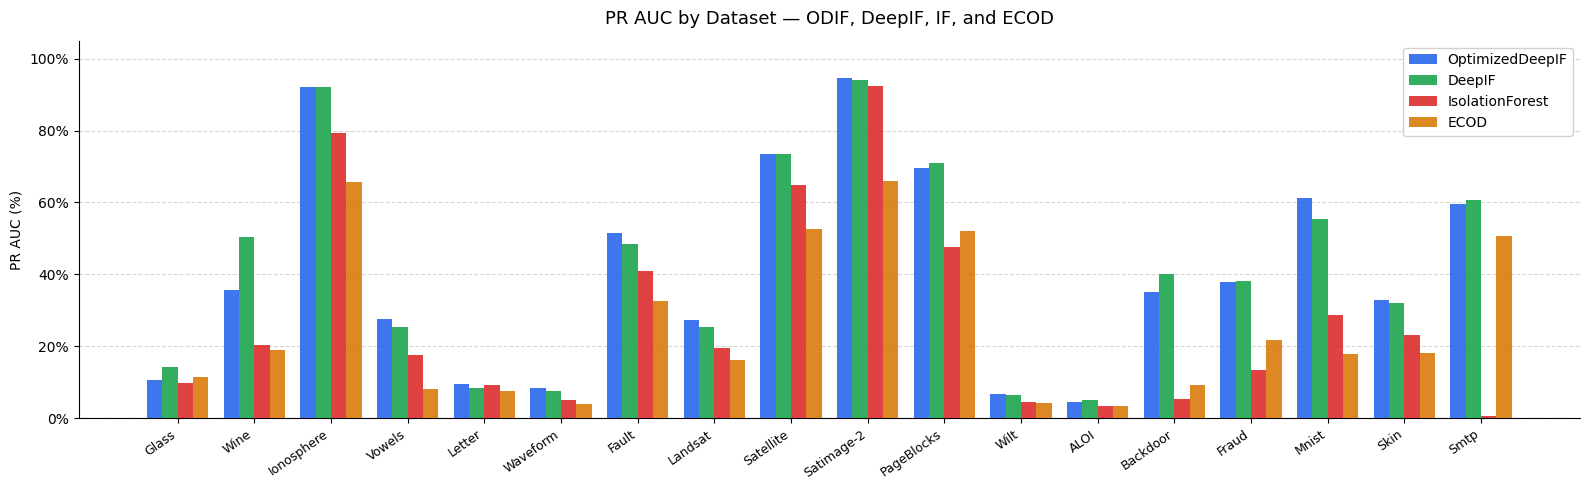

✅ Bar chart saved to fig_prauc_bar_chart.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Full results (from experiment) ────────────────────────────────────────────
data = {
    'Dataset':         ['Glass','Wine','Ionosphere','Vowels','Letter','Waveform',
                        'Fault','Landsat','Satellite','Satimage-2','PageBlocks','Wilt',
                        'ALOI','Backdoor','Fraud','Mnist','Skin','Smtp'],
    'OptimizedDeepIF': [10.7,35.8,92.2,27.7, 9.5, 8.5,51.5,27.2,73.5,94.7,69.7, 6.8,
                         4.6,35.0,37.8,61.2,32.8,59.7],
    'DeepIF':          [14.2,50.3,92.1,25.3, 8.3, 7.5,48.4,25.3,73.6,94.1,70.9, 6.6,
                         5.2,40.1,38.2,55.5,32.1,60.7],
    'IsolationForest': [ 9.7,20.5,79.4,17.5, 9.3, 5.2,41.0,19.6,64.8,92.5,47.7, 4.4,
                         3.3, 5.3,13.5,28.7,23.1, 0.5],
    'ECOD':            [11.5,19.1,65.7, 8.1, 7.7, 4.1,32.6,16.3,52.6,66.0,52.0, 4.2,
                         3.3, 9.2,21.7,17.8,18.2,50.7],
}

df = pd.DataFrame(data).set_index('Dataset')
ALGORITHMS = ['OptimizedDeepIF', 'DeepIF', 'IsolationForest', 'ECOD']
PALETTE    = {'OptimizedDeepIF': '#2563eb', 'DeepIF': '#16a34a',
              'IsolationForest': '#dc2626', 'ECOD': '#d97706'}

# ── Average & Median rows ──────────────────────────────────────────────────────
avg_row = pd.DataFrame(df.mean().round(1)).T; avg_row.index = ['Average']
med_row = pd.DataFrame(df.median().round(1)).T; med_row.index = ['Median']
df_table = pd.concat([df, avg_row, med_row])

# ── Styled table ───────────────────────────────────────────────────────────────
def highlight_best(row):
    vals = pd.to_numeric(row, errors='coerce')
    styles = [''] * len(row)
    if vals.notna().any():
        best = vals.idxmax()
        styles[row.index.get_loc(best)] = 'font-weight: bold; color: #1d4ed8'
    return styles

styled = (
    df_table.style
    .format('{:.1f}%')
    .apply(highlight_best, axis=1)
    .set_caption('PR AUC Results — Our Experiments (4 Algorithms × 18 Datasets)')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','14px'),('font-weight','bold'),('padding-bottom','8px')]},
        {'selector': 'th',      'props': [('text-align','center'),('padding','6px 12px')]},
        {'selector': 'td',      'props': [('text-align','center'),('padding','5px 12px')]},
        {'selector': 'tr:last-child, tr:nth-last-child(2)',
                                'props': [('border-top','2px solid #888'),('font-style','italic')]},
    ])
    .background_gradient(cmap='YlGn', subset=pd.IndexSlice[df.index, :], vmin=0, vmax=100)
)
display(styled)

# ── Bar chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

x      = np.arange(len(df))
n_algs = len(ALGORITHMS)
width  = 0.2

for i, alg in enumerate(ALGORITHMS):
    offset = (i - n_algs / 2 + 0.5) * width
    bars = ax.bar(x + offset, df[alg], width,
                  label=alg, color=PALETTE[alg], alpha=0.88, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(df.index, rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_ylabel('PR AUC (%)')
ax.set_title('PR AUC by Dataset — ODIF, DeepIF, IF, and ECOD', fontsize=13, pad=12)
ax.legend(loc='upper right', framealpha=0.9)
ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_prauc_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Bar chart saved to fig_prauc_bar_chart.png')